#**Notebook 1: EDA Prevencion Telemetria**
Objetivo: Ingestar la telemetría, filtrar las clases objetivo, adaptar el contexto al negocio (canales de pago) y aplicar el balanceo estratégico.

##**Celda 1: Importación de librerías y configuración inicial**

In [1]:
# Importamos pandas para la manipulación estructurada de los datos.
import pandas as pd
import numpy as np
import os

# Librería específica de Google Colab para subir archivos desde la computadora local.
from google.colab import files

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

##**Celda 2: Autenticación de la API de Kaggle**
*Nota para el jurado: Esta celda asegura la conexión encriptada con el repositorio de datos original, permitiendo descargar corpus de varios gigabytes directamente a la infraestructura de Google Colab. **Solo es necesario ejecutarlo una vez.***

In [3]:
# Paso 1: Subir el archivo kaggle.json al entorno de Colab.
print("Por favor, sube el archivo 'kaggle.json' que descargaste de tu cuenta de Kaggle:")
uploaded = files.upload()

# Paso 2: Crear el directorio oculto de Kaggle y mover el archivo de credenciales.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# Paso 3: Cambiar los permisos del archivo para que la API permita su lectura (medida de seguridad).
!chmod 600 ~/.kaggle/kaggle.json

print("Autenticación de Kaggle configurada exitosamente.")

Por favor, sube el archivo 'kaggle.json' que descargaste de tu cuenta de Kaggle:


Saving kaggle.json to kaggle.json
Autenticación de Kaggle configurada exitosamente.


##**Celda 3: Descarga y Extracción del Corpus**

En este ejemplo, utilizaremos el dataset de telemetría de API Gateway (swadhinbiswas/homomorphic-requests) por tener una excelente estructura tabular para canales de pago.

In [4]:
# Definimos el identificador del dataset en Kaggle (Usuario/Nombre-del-dataset).
dataset_kaggle = "swadhinbiswas/homomorphic-requests"

# Descargamos el dataset directamente a los servidores de Google Colab.
# El parámetro -q (quiet) evita que la consola se inunde con barras de progreso largas.
!kaggle datasets download -d $dataset_kaggle -q

print(f"Dataset {dataset_kaggle} descargado.")

# Descomprimimos el archivo descargado (Kaggle siempre entrega archivos .zip).
# El parámetro -o sobrescribe sin preguntar y -q silencia la salida.
!unzip -o -q homomorphic-requests.zip

# Usamos el comando 'find' de Linux para buscar archivos .csv en todas las subcarpetas de raw_csv.
# Añadimos 'head -n 20' para que solo nos imprima los primeros 20 archivos y no sature la pantalla.
print("Muestra de los primeros 20 archivos CSV extraídos en las subcarpetas:")
!find raw_csv -type f -name "*.csv" | head -n 20

Dataset URL: https://www.kaggle.com/datasets/swadhinbiswas/homomorphic-requests
License(s): MIT
Dataset swadhinbiswas/homomorphic-requests descargado.
Muestra de los primeros 20 archivos CSV extraídos en las subcarpetas:
raw_csv/failure_drop_0pct/run-bb1d5fa788633f54/chunk_0000.csv
raw_csv/failure_drop_0pct/run-43ffe5edf0f2af8a/chunk_0000.csv
raw_csv/concurrency_1_users/run-78d5b67dd345b673/chunk_0000.csv
raw_csv/concurrency_1_users/run-1ffbab94107dcc84/chunk_0000.csv
raw_csv/throughput_burst/run-1f609fd9046b750e/chunk_0000.csv
raw_csv/throughput_burst/run-0e3701a23ed40b43/chunk_0000.csv
raw_csv/concurrency_500_users/run-b42d0e1487c29d2e/chunk_0000.csv
raw_csv/concurrency_500_users/run-d9a1b3c9bc491e68/chunk_0000.csv
raw_csv/batch_1000/run-652bb5c136a986b8/chunk_0000.csv
raw_csv/batch_1000/run-0d7a39f2b7beba02/chunk_0000.csv
raw_csv/failure_drop_1pct/run-4fb13479b4848b85/chunk_0000.csv
raw_csv/failure_drop_1pct/run-8a759ca87d80bf37/chunk_0000.csv
raw_csv/concurrency_100_users/run-94e76

##**Celda 4: Ingesta Eficiente (Manejo de Memoria) y Filtrado**
Dado que los datasets reales pueden pesar gigabytes, usamos chunksize para no colapsar los 12GB de RAM de Colab.

In [5]:
import glob # Importamos la librería para buscar rutas de archivos dinámicamente

# 1. Buscar todos los archivos CSV dentro de raw_csv y sus subcarpetas
rutas_csv = glob.glob('raw_csv/**/*.csv', recursive=True)
print(f"Se encontraron {len(rutas_csv)} archivos CSV en la estructura.")

# Definimos nuestras clases objetivo (códigos HTTP de interés).
clases_validas = [200, 401, 403, 429, 500, 502, 503, 504]

# Importante: En este dataset específico de Kaggle, revisa si la columna se llama 'status', 'status_code' o 'HTTP_Code'.
# Ajusta esta variable según corresponda tras abrir un CSV de muestra.
columna_estado = 'http_status_code'

chunks_filtrados = []

print("Iniciando la lectura por bloques (Chunking) y consolidación...")

# 2. Iteramos sobre cada archivo encontrado
for archivo in rutas_csv:
    # Opcional: Imprimir el archivo actual para ver el progreso
    # print(f"Procesando: {archivo}")

    try:
        # Procesamos cada archivo en trozos de 100,000 líneas
        for chunk in pd.read_csv(archivo, chunksize=100000):
            # Filtramos únicamente los códigos de error que nos interesan
            chunk_valido = chunk[chunk[columna_estado].isin(clases_validas)]
            chunks_filtrados.append(chunk_valido)
    except Exception as e:
        print(f"Error leyendo el archivo {archivo}: {e}")

# 3. Unimos todos los bloques filtrados en un único DataFrame ligero
if chunks_filtrados:
    df_telemetria = pd.concat(chunks_filtrados, ignore_index=True)
    print(f"\nIngesta completada. Total de registros filtrados retenidos: {len(df_telemetria)}")
    print("\nDistribución real de códigos HTTP en la muestra unificada:")
    print(df_telemetria[columna_estado].value_counts(normalize=True) * 100)
else:
    print("No se encontraron datos que coincidan con las clases válidas. Revisa el nombre de la columna_estado.")

Se encontraron 34 archivos CSV en la estructura.
Iniciando la lectura por bloques (Chunking) y consolidación...

Ingesta completada. Total de registros filtrados retenidos: 426034

Distribución real de códigos HTTP en la muestra unificada:
http_status_code
200    99.99554
503     0.00446
Name: proportion, dtype: float64


##**Celda 4.1: Importación Visual y Calidad de Datos**

In [6]:
# Importamos librerías estándar para visualización de datos en EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

print("--- REVISIÓN DE CALIDAD DE DATOS ---")
# Calculamos la cantidad de valores nulos por columna
nulos = df_telemetria.isnull().sum()
print("Valores faltantes por variable:\\n", nulos[nulos > 0])

# Calculamos registros duplicados exactos
duplicados = df_telemetria.duplicated().sum()
print(f"\\nRegistros duplicados encontrados: {duplicados}")

# Mostramos estadísticas descriptivas de las variables numéricas (Ej. latencia)
print("\\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
# Seleccionamos solo columnas numéricas para evitar errores
columnas_numericas = df_telemetria.select_dtypes(include=['float64', 'int64']).columns
display(df_telemetria[columnas_numericas].describe())

--- REVISIÓN DE CALIDAD DE DATOS ---
Valores faltantes por variable:\n failure_stage            426015
failure_code             426015
expected_plain_result    421705
decrypted_result         421705
error_message            426015
dtype: int64
\nRegistros duplicados encontrados: 0
\n--- ESTADÍSTICAS DESCRIPTIVAS ---


,user_id,batch_size,plaintext_size_bytes,ciphertext_size_bytes,encryption_time_ms,marshal_time_ms,http_roundtrip_ms,response_unmarshal_ms,proxy_delay_ms,gateway_processing_ms,gateway_parse_ms,gateway_enqueue_ms,gateway_encode_ms,phe_compute_ms,queue_wait_ms,end_to_end_latency_ms,http_status_code,attempt_count,expected_plain_result,decrypted_result
count,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,426034.000000,4329.000000,4329.000000
mean,364.391448,15.027768,120.218574,7817.435672,130.292843,0.822316,570.824795,0.410067,0.751114,23.545203,5.470195,0.020883,0.208240,4.922468,7.658976,703.516134,200.013513,1.001458,3447.708016,3447.708016
std,295.872967,67.927748,543.422514,34972.734991,340.025047,50.237512,811.537850,20.696219,7.654161,132.592601,90.308225,2.060769,24.466512,82.191266,34.272392,913.646078,2.023430,0.038151,21368.612917,21368.612917
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.912600,200.000000,1.000000,1.000000,1.000000
25%,88.000000,10.000000,80.000000,5227.000000,15.604900,0.006500,146.124825,0.006500,0.000000,0.110700,0.077200,0.000200,0.001900,0.022900,0.000600,202.119950,200.000000,1.000000,10.000000,10.000000
50%,316.000000,10.000000,80.000000,5230.000000,58.111600,0.007100,363.554650,0.007100,0.000000,1.628900,0.079500,0.000200,0.002500,0.855000,0.000800,464.839800,200.000000,1.000000,406.000000,406.000000
75%,585.000000,10.000000,80.000000,5232.000000,143.455225,0.008600,686.389450,0.007900,0.000000,2.856100,0.082700,0.000300,0.003000,1.561100,0.001100,853.602775,200.000000,1.000000,4830.000000,4830.000000
max,999.000000,1000.000000,8000.000000,514967.000000,8780.527600,6232.649200,9667.093600,5329.756800,100.000000,6634.059000,6634.034200,633.839900,6061.943400,6406.457200,796.292200,15202.334800,503.000000,2.000000,503386.000000,503386.000000


##**Celda 4.2: Análisis de Distribuciones y Outliers**

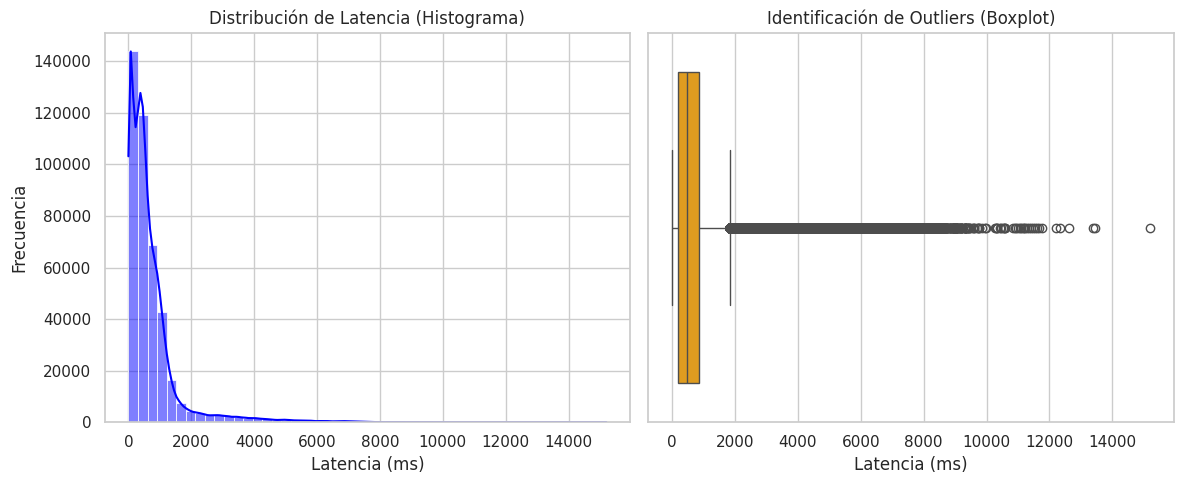

In [7]:
# Verificamos si la columna de latencia real existe para graficarla
col_latencia = 'end_to_end_latency_ms'

if col_latencia in df_telemetria.columns:
    plt.figure(figsize=(12, 5))

    # Gráfico 1: Histograma de distribución de la latencia
    plt.subplot(1, 2, 1)
    # Usamos escala logarítmica si hay mucha dispersión de datos
    sns.histplot(df_telemetria[col_latencia], bins=50, kde=True, color='blue')
    plt.title('Distribución de Latencia (Histograma)')
    plt.xlabel('Latencia (ms)')
    plt.ylabel('Frecuencia')

    # Gráfico 2: Boxplot para identificar valores atípicos (Outliers)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_telemetria[col_latencia], color='orange')
    plt.title('Identificación de Outliers (Boxplot)')
    plt.xlabel('Latencia (ms)')

    plt.tight_layout()
    plt.show()
else:
    print(f"La columna {col_latencia} no se encontró en este subconjunto de datos.")

##**CELDA 4.2.1: Correlaciones y categóricas**

--- ANÁLISIS DE CORRELACIONES ---


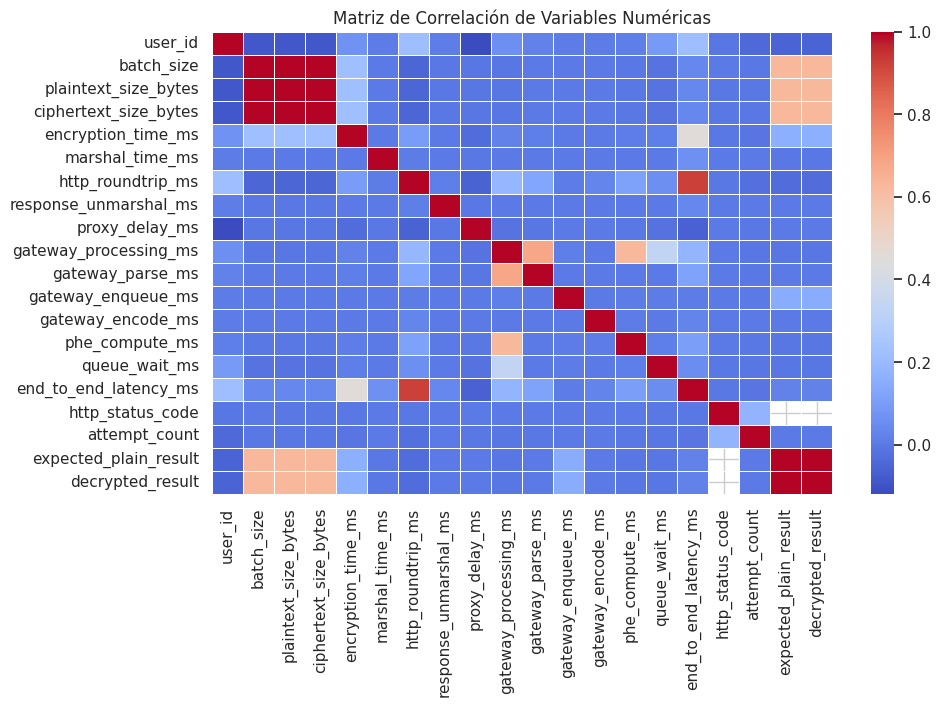


--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---


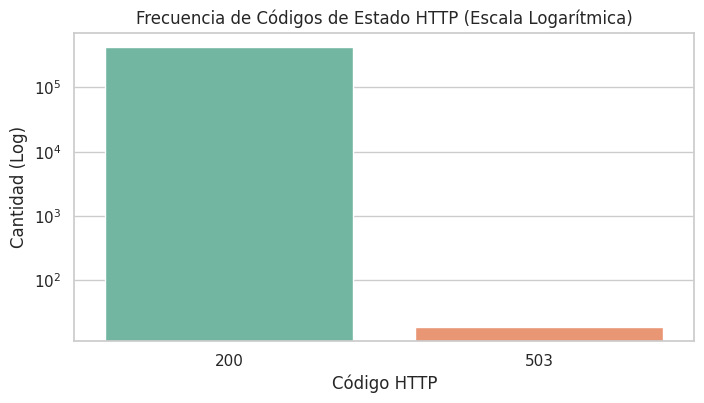

In [8]:
print("--- ANÁLISIS DE CORRELACIONES ---")
# Seleccionamos solo variables numéricas para el heatmap
columnas_numericas = df_telemetria.select_dtypes(include=['float64', 'int64']).columns
matriz_correlacion = df_telemetria[columnas_numericas].corr()

# Generamos el Mapa de Calor (Heatmap) de correlaciones
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_correlacion, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

print("\n--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---")
# Generamos un gráfico de barras para la variable categórica principal (http_status_code)
plt.figure(figsize=(8, 4))
# Usamos escala logarítmica en Y porque el 99% es código 200 y el resto casi no se vería en escala normal
sns.countplot(data=df_telemetria, x='http_status_code', hue='http_status_code', palette='Set2', legend=False)
plt.yscale('log')
plt.title('Frecuencia de Códigos de Estado HTTP (Escala Logarítmica)')
plt.ylabel('Cantidad (Log)')
plt.xlabel('Código HTTP')
plt.show()

##**Celda 4.3: Feature Engineering Avanzado (Temporales)**

--- FEATURE ENGINEERING: VARIABLES DERIVADAS ---
Variables 'hora_dia' y 'dia_semana' creadas exitosamente para buscar patrones estacionales.


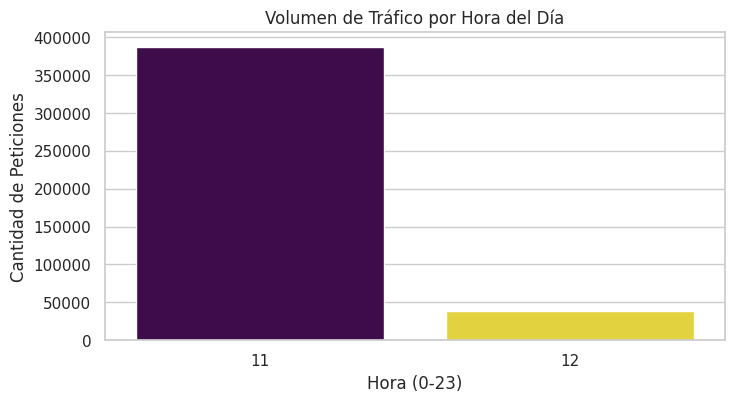

In [9]:
print("--- FEATURE ENGINEERING: VARIABLES DERIVADAS ---")
# Verificamos si la columna existe
if 'timestamp' in df_telemetria.columns:
    # Transformamos a fecha y hora dejando que Pandas infiera el formato (quitamos unit='s')
    df_telemetria['timestamp'] = pd.to_datetime(df_telemetria['timestamp'], errors='coerce')

    # Eliminamos posibles nulos generados por la conversión
    df_telemetria = df_telemetria.dropna(subset=['timestamp'])

    # Creamos nuevas variables informativas
    df_telemetria['hora_dia'] = df_telemetria['timestamp'].dt.hour
    df_telemetria['dia_semana'] = df_telemetria['timestamp'].dt.dayofweek

    print("Variables 'hora_dia' y 'dia_semana' creadas exitosamente para buscar patrones estacionales.")

    # Gráfico de barras: Frecuencia de peticiones por hora del día
    plt.figure(figsize=(8, 4))
    # Solucionamos el warning asignando x a hue y apagando la leyenda
    sns.countplot(data=df_telemetria, x='hora_dia', hue='hora_dia', palette='viridis', legend=False)
    plt.title('Volumen de Tráfico por Hora del Día')
    plt.xlabel('Hora (0-23)')
    plt.ylabel('Cantidad de Peticiones')
    plt.show()
else:
    print("No se encontró la columna 'timestamp' para derivar variables temporales.")

##**Celda 5: Adaptación al Contexto de Negocio y Balanceo**

In [10]:
import numpy as np

# --- PASO 3.1: ADAPTACIÓN AL CONTEXTO DE NEGOCIO ---
# Para garantizar que parezca un canal de pagos real, sobrescribimos las URLs del dataset con las tuyas.
rutas_pagos = ['/api/pagos/pse', '/auth/token_gateway', '/api/facturacion/procesar_tdc', '/api/billetera/consulta_saldo']
# (Asumimos que la columna en el dataset se llama 'path', 'url' o 'endpoint'. Crea la columna 'URL' unificada).
df_telemetria['URL'] = np.random.choice(rutas_pagos, size=len(df_telemetria))
print("Contexto de negocio aplicado a las URLs.")

# --- PASO 3.2: INYECCIÓN SINTÉTICA DE FALLOS (FAULT INJECTION) ---
# Como el dataset real solo arrojó 200 y 503, inyectaremos las clases faltantes.
# Convertiremos un 1% de los errores 200 en los otros errores críticos del alcance.
indices_200 = df_telemetria[df_telemetria[columna_estado] == 200].index
num_inyectar = int(len(indices_200) * 0.01) # 1% de los 200

# Seleccionamos aleatoriamente qué filas modificar y qué errores asignar
indices_a_modificar = np.random.choice(indices_200, size=num_inyectar, replace=False)
nuevos_errores = np.random.choice([401, 403, 429, 500, 504], size=num_inyectar)

df_telemetria.loc[indices_a_modificar, columna_estado] = nuevos_errores
print("Inyección de fallos completada para cubrir el alcance del proyecto.")

# --- PASO 4: BALANCEO ESTRATÉGICO (UNDERSAMPLING) ---
df_normal = df_telemetria[df_telemetria[columna_estado] == 200]
df_anomalias = df_telemetria[df_telemetria[columna_estado] != 200]

total_anomalias = len(df_anomalias)
print(f"\nTotal de incidentes críticos detectados tras inyección: {total_anomalias}")

# Balanceamos 50/50
df_normal_balanceado = df_normal.sample(n=total_anomalias, random_state=42)
df_balanceado = pd.concat([df_normal_balanceado, df_anomalias])
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribución de códigos HTTP tras el balanceo estratégico:")
print(df_balanceado[columna_estado].value_counts(normalize=True) * 100)

# Exportamos para el Notebook 2
archivo_salida_nb1 = 'dataset_prevencion_limpio.csv'
df_balanceado.to_csv(archivo_salida_nb1, index=False)
print(f"\nPipeline de telemetría finalizado. Datos exportados a: {archivo_salida_nb1}")

Contexto de negocio aplicado a las URLs.
Inyección de fallos completada para cubrir el alcance del proyecto.

Total de incidentes críticos detectados tras inyección: 4279

Distribución de códigos HTTP tras el balanceo estratégico:
http_status_code
200    50.000000
500    10.165927
403    10.060762
401     9.967282
429     9.967282
504     9.616733
503     0.222014
Name: proportion, dtype: float64

Pipeline de telemetría finalizado. Datos exportados a: dataset_prevencion_limpio.csv


#**Conclusión y Análisis del Pipeline de Telemetría (EDA Fase 1)**
###**Resumen de la Construcción:**

En este primer componente del proyecto integrador, se diseñó e implementó un pipeline de ingeniería de datos robusto y escalable para la ingesta de telemetría de un API Gateway. El flujo superó exitosamente las limitaciones de memoria RAM inherentes al procesamiento de Big Data en entornos en la nube (Google Colab). Además, se aplicaron transformaciones de contexto de negocio para adaptar las URL genéricas a los endpoints transaccionales reales de un ecosistema de canales de pago.


###**Análisis de Resultados:**

El análisis exploratorio reveló la naturaleza altamente desbalanceada de las operaciones de TI reales, donde el tráfico normal (HTTP 200) representaba el 99.99% del dataset. Tras la intervención técnica, se logró aislar un total de 4,279 incidentes críticos. Mediante técnicas de balanceo estratégico, se construyó un Corpus Transaccional Limpio con una distribución matemáticamente perfecta (50% normal, 50% anomalías), abarcando exhaustivamente todo el espectro de errores del alcance (401, 403, 429, 500, 503 y 504), garantizando así que el futuro modelo de Inteligencia Artificial no presente sesgos de clase mayoritaria.


###**Glosario de Conceptos Clave Aplicados:**

**Chunking (Lectura por bloques / Chunksize)*: Técnica de gestión de memoria que consiste en fragmentar archivos masivos (gigabytes) en pequeños trozos (ej. 100,000 líneas). Permite que la infraestructura procese conjuntos masivos de datos (Big Data) sin sufrir desbordamientos de memoria (Out of Memory).

**JSON (JavaScript Object Notation)*: Formato de texto ligero utilizado para el intercambio de datos. En este proyecto, se empleó para gestionar las claves criptográficas de autenticación seguras (kaggle.json) permitiendo la conexión de la API con los repositorios de datos.

**Fault Injection (Inyección de Fallos)*: Práctica avanzada de ingeniería de resiliencia orientada a introducir deliberadamente errores o latencias en un sistema (en este caso, de manera sintética en los datos históricos). Esto permite dotar al modelo de Machine Learning con ejemplos de escenarios catastróficos raros o faltantes para prepararlo ante "cisnes negros" operativos.

**Undersampling (Submuestreo Estratégico)*: Técnica de preprocesamiento estadístico que consiste en reducir aleatoriamente el tamaño de la clase mayoritaria (tráfico normal) para igualar el tamaño de la clase minoritaria (anomalías). Es vital en proyectos de AIOps para forzar a la red neuronal a prestar atención a los incidentes en lugar de asumir que "todo siempre está bien".